This script investigates the variation in the free parameters that gives a certain L2 error over a set of equilibria

In [21]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import importlib.util
import sys
from pathlib import Path
from scipy.interpolate import interp1d
ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT))
from src.solver_nondim import saarelma_connor_nondim

# Global parameters
equil_num = 100
err_frac = 0.50
perc_success = 0.90
bc_type = "neumann"

GEQDSK_DIR = Path("/mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks")
PFILE_DIR = Path("/mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles")
scan_success_dir = Path('scan_results_eqdbOak_100_4/')

In [2]:
# Add some more files
success_fp = Path('success_PTHmode.txt')
failure_fp = Path('failure_PTHmode.txt')
error_messages_fp = Path('error_messages_PTHmode.txt')

In [3]:
from collections import defaultdict


def initialize_inputs(equil_num, geqdsk_dir=GEQDSK_DIR, pfile_dir=PFILE_DIR):
    """Select equil_num g/p file pairs from the CAKE input directories.

    Files are named g{shot}.{time} and p{shot}.{time}. Selection prioritizes
    one equilibrium per shot number before adding additional times from shots
    that already have a selected equilibrium.
    """
    geqdsk_dir = Path(geqdsk_dir)
    pfile_dir = Path(pfile_dir)

    g_by_suffix = {
        f.name[1:]: f for f in geqdsk_dir.glob("g*") if f.is_file()
    }
    p_by_suffix = {
        f.name[1:]: f for f in pfile_dir.glob("p*") if f.is_file()
    }
    shared_suffixes = sorted(set(g_by_suffix) & set(p_by_suffix))

    by_shot = defaultdict(list)
    for suffix in shared_suffixes:
        shot, time = suffix.split(".", 1)
        by_shot[shot].append((time, suffix))
    for shot in by_shot:
        by_shot[shot].sort()

    shots = sorted(by_shot)
    selected = []
    time_idx = 0
    while len(selected) < equil_num:
        added_this_round = False
        for shot in shots:
            if len(selected) >= equil_num:
                break
            entries = by_shot[shot]
            if time_idx < len(entries):
                suffix = entries[time_idx][1]
                selected.append(
                    (str(g_by_suffix[suffix]), str(p_by_suffix[suffix]))
                )
                added_this_round = True
        if not added_this_round:
            break
        time_idx += 1

    if len(selected) < equil_num:
        raise ValueError(
            f"Requested {equil_num} equilibria but only found {len(selected)} "
            f"matching g/p pairs in {geqdsk_dir} and {pfile_dir}"
        )

    print(f"Selected {len(selected)} g/p file pairs:")
    for mhd_fp, kprof_fp in selected:
        print(f"  g: {mhd_fp}\n  p: {kprof_fp}")
    return selected


equilibria = initialize_inputs(equil_num)

Selected 100 g/p file pairs:
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g150840.03000
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p150840.03000
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g152960.03500
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p152960.03500
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g153032.04475
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p153032.04475
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g153100.03000
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p153100.03000
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g153140.04750
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p153140.04750
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g153153.03800
  p: /mnt/homes_global/jal2351/software/sc_inputs/CAKEpfiles/p153153.03800
  g: /mnt/homes_global/jal2351/software/sc_inputs/CAKEgeqdsks/g15

Plotting and analysis

In [19]:
# Load successful runs with normalized L2 (err_frac) below the threshold set in cell 1.
import csv

success_fp = 'success_PTHmode.txt'


def ne_npy_path(eq_dir, ac, ck, de, nf, nc, psi_val):
    """Match filename convention used in the scan cell."""
    return eq_dir / f"ne_a{ac}_C{ck}_D{de}_n{nf}_nc{nc}_b{psi_val:.4f}.npy"


# filtered_runs[eq_tag] -> list of run dicts passing the err_frac cut
filtered_runs = {}
# flat list of all kept runs (same dicts as above)
good_runs_all = []

n_success_total = 0
n_kept_total = 0

for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    eq_dir = scan_success_dir / eq_tag
    # success_path = eq_dir / success_fp.name
    success_path = eq_dir / success_fp
    if not success_path.exists():
        print(f"[skip] no success log for {eq_tag}")
        continue

    eq_runs = []
    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader)  # header
        for row in reader:
            if len(row) < 8:
                continue
            n_success_total += 1
            _, ac, ck, de, nf, nc, psi_b, l2 = [x.strip() for x in row[:8]]
            ac, ck, de, nf, nc = float(ac), float(ck), float(de), float(nf), float(nc)
            psi_b = float(psi_b)
            l2 = float(l2)

            if l2 >= err_frac:
                continue

            npy_path = ne_npy_path(eq_dir, ac, ck, de, nf, nc, psi_b)
            if not npy_path.exists():
                continue

            sol = np.load(npy_path, allow_pickle=True).item()
            run = dict(
                eq_tag=eq_tag,
                mhd_fp=mhd_fp,
                kprof_fp=kprof_fp,
                alpha_crit=ac,
                C_KBM=ck,
                De_chie_etg=de,
                nFC_x0=nf,
                ncx_x0_ratio=nc,
                psi_N_inner=psi_b,
                norm_L2_error=l2,
                x=np.asarray(sol["x"], dtype=float),
                ne=np.asarray(sol["y"], dtype=float),
                nFC=np.asarray(sol.get("nFC", []), dtype=float),
                nCX=np.asarray(sol.get("nCX", []), dtype=float),
                npy_path=str(npy_path),
            )
            eq_runs.append(run)
            good_runs_all.append(run)
            n_kept_total += 1

    if eq_runs:
        filtered_runs[eq_tag] = eq_runs

print(f"Loaded {n_kept_total} / {n_success_total} successful runs "
      f"with err_frac < {err_frac:g}")
print(f"Equilibria with at least one good run: {len(filtered_runs)} / {len(equilibria)}")

Loaded 18987 / 84343 successful runs with err_frac < 0.25
Equilibria with at least one good run: 100 / 100


In [22]:
# For each parameter combination, keep it if L2 < err_frac on at least
# perc_success fraction of all equilibria (from cell 1).
import csv
from collections import defaultdict

PARAM_NAMES = ("alpha_crit", "C_KBM", "De_chie_etg", "nFC_x0", "ncx_x0_ratio")


def param_key(ac, ck, de, nf, nc):
    return (round(float(ac), 3), round(float(ck), 3),
            round(float(de), 3), round(float(nf), 3), round(float(nc), 3))


# combo_stats[key] -> list of per-equilibrium outcomes for that 5D combo
combo_stats = defaultdict(list)

for mhd_fp, kprof_fp in equilibria:
    eq_tag = Path(mhd_fp).name[1:]
    success_path = scan_success_dir / eq_tag / success_fp
    if not success_path.exists():
        continue

    with open(success_path, newline="") as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if len(row) < 8:
                continue
            _, ac, ck, de, nf, nc, psi_b, l2 = [x.strip() for x in row[:8]]
            key = param_key(ac, ck, de, nf, nc)
            l2 = float(l2)
            combo_stats[key].append(dict(
                eq_tag=eq_tag,
                norm_L2_error=l2,
                passed=l2 < err_frac,
            ))

n_equilibria_total = len(equilibria)

# filtered_combos[key] -> summary + loaded profiles for passing equilibria
filtered_combos = {}

for key, outcomes in combo_stats.items():
    n_pass = sum(1 for o in outcomes if o["passed"])
    success_fraction = n_pass / n_equilibria_total

    if success_fraction < perc_success:
        continue

    # Attach full run dicts (with profiles) from cell above where available
    runs = [
        r for r in good_runs_all
        if param_key(r["alpha_crit"], r["C_KBM"], r["De_chie_etg"],
                     r["nFC_x0"], r["ncx_x0_ratio"]) == key
    ]
    passing_eq_tags = {o["eq_tag"] for o in outcomes if o["passed"]}

    filtered_combos[key] = dict(
        params=dict(zip(PARAM_NAMES, key)),
        n_equilibria_passing=n_pass,
        n_equilibria_total=n_equilibria_total,
        success_fraction=success_fraction,
        per_equilibrium=outcomes,
        passing_eq_tags=sorted(passing_eq_tags),
        runs=runs,
        mean_err_frac=float(np.mean([o["norm_L2_error"] for o in outcomes if o["passed"]])),
        max_err_frac=float(np.max([o["norm_L2_error"] for o in outcomes if o["passed"]])),
    )

# Parameter ranges spanned by robust combinations
param_ranges_robust = {}
if filtered_combos:
    for name in PARAM_NAMES:
        vals = [d["params"][name] for d in filtered_combos.values()]
        param_ranges_robust[name] = (min(vals), max(vals))

print(f"Kept {len(filtered_combos)} / {len(combo_stats)} parameter combinations "
      f"with success_fraction >= {perc_success:g} "
      f"({perc_success * 100:.0f}% of {n_equilibria_total} equilibria)")
if param_ranges_robust:
    print(f"Parameter ranges over robust combinations (normalized L2 error < {err_frac}):")
    for name, (lo, hi) in param_ranges_robust.items():
        print(f"  {name}: [{lo:g}, {hi:g}]")
else:
    print("No combinations met the perc_success threshold — try lowering perc_success or err_frac.")

Kept 4 / 1024 parameter combinations with success_fraction >= 0.9 (90% of 100 equilibria)
Parameter ranges over robust combinations (normalized L2 error < 0.5):
  alpha_crit: [0.1, 0.1]
  C_KBM: [0.464, 2.154]
  De_chie_etg: [0.1, 0.464]
  nFC_x0: [1e+16, 1e+17]
  ncx_x0_ratio: [1.259, 17.783]


Plotted 46 / 100 equilibria using 4 robust combinations (quantity: ne)
Skipped (no robust-combo run data): ['150840.03000', '152960.03500', '153100.03000', '153140.04750', '153153.03800', '153646.04200', '153649.03950', '153651.03900', '153657.04100', '153659.04350', '153661.04100', '153682.02750', '153702.03950', '153779.02140', '153780.02209', '153783.02600', '153823.02900', '153824.04700', '153833.03000', '153834.02900', '153839.04000', '153840.02800', '154083.04300', '154372.04000', '154842.04100', '154849.02075', '154864.03300', '154929.02200', '155623.03300', '156823.04300', '156826.04300', '156827.04300', '156855.04500', '156859.04500', '156864.03600', '156867.02000', '157102.02000', '157303.03600', '157308.04200', '157312.04575', '157369.02000', '157371.02000', '157372.02000', '157373.02110', '157374.04800', '157376.02000', '157379.02175', '157381.03200', '157418.03000', '157420.03000', '158036.03085', '158071.03500', '158074.03600', '158088.04000']


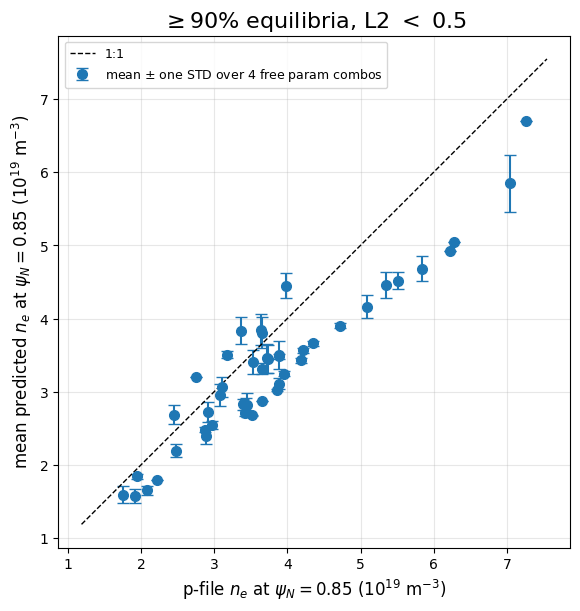

In [23]:
# Compare p-file vs mean model prediction at psi_N_plot for every equilibrium.
# Plot the *unspecified* inner BC quantity:
#   bc_type == "neumann"  -> n_e emerges      -> compare n_e
#   bc_type == "dirichlet" -> dne/dx emerges -> compare dn_e/dx
# Requires cells 7–8 (filtered_combos, good_runs_all).

from collections import defaultdict

psi_N_plot = 0.85  # psi_N at which to sample

def read_pfile_ne(path):
    psi_arr, ne_arr = [], []
    in_ne_block = False
    with open(path) as f:
        for line in f:
            if "3 N Z A" in line:
                break
            if line.startswith("201"):
                in_ne_block = "ne(10^20/m^3)" in line
                continue
            if in_ne_block:
                psi, val, _ = line.split()
                psi_arr.append(float(psi))
                ne_arr.append(float(val))
    return np.array(psi_arr), np.array(ne_arr) * 1e20

def value_at_psi(x_grid, y_grid, x_at_psi):
    return float(interp1d(
        x_grid, y_grid, kind="linear",
        bounds_error=False, fill_value="extrapolate",
    )(x_at_psi))

if bc_type == "neumann":
    plot_quantity = "ne"
elif bc_type == "dirichlet":
    plot_quantity = "dne_dx"
else:
    raise ValueError(f"bc_type must be 'neumann' or 'dirichlet', got {bc_type!r}")

if not filtered_combos:
    print("No robust combinations in filtered_combos — run cells 7–8 first.")
else:
    combo_runs_by_eq = defaultdict(list)
    for combo in filtered_combos.values():
        for run in combo["runs"]:
            combo_runs_by_eq[run["eq_tag"]].append(run)

    pfile_cache = {}
    geometry_cache = {}
    pfile_pts = []
    pred_mean_pts = []
    pred_std_pts = []
    eq_labels = []
    skipped = []

    for mhd_fp, kprof_fp in equilibria:
        eq_tag = Path(mhd_fp).name[1:]
        runs = combo_runs_by_eq.get(eq_tag, [])
        if not runs:
            skipped.append(eq_tag)
            continue

        if plot_quantity == "ne":
            # Scan used psi_N_inner = 0.85, so sample at the inner boundary x.
            x_at_psi = min(float(r["x"].min()) for r in runs)

            if kprof_fp not in pfile_cache:
                pfile_cache[kprof_fp] = read_pfile_ne(kprof_fp)
            psi_pfile, ne_pfile = pfile_cache[kprof_fp]
            pfile_val = float(interp1d(
                psi_pfile, ne_pfile, kind="linear",
                bounds_error=False, fill_value="extrapolate",
            )(psi_N_plot))

            pred_vals = [
                value_at_psi(r["x"], r["ne"], x_at_psi)
                for r in runs
            ]
        else:
            # Dirichlet case still needs psi_N -> x mapping from equilibrium geometry.
            if eq_tag not in geometry_cache:
                ref = saarelma_connor_nondim(
                    P_tot_e=5e6,
                    alpha_crit=0,
                    C_KBM=0,
                    De_chie_etg=0,
                    nFC_x0=0,
                    ncx_x0_ratio=0,
                    mhd_fp=mhd_fp,
                    kprof_fp=kprof_fp,
                    verbose=False,
                )
                ref.setup_solver_grids(res=40)
                geometry_cache[eq_tag] = ref
            ref = geometry_cache[eq_tag]

            psi_to_x = interp1d(
                ref.psi_N_pres, ref.x_init,
                kind="linear", bounds_error=False, fill_value="extrapolate",
            )
            x_at_psi = float(psi_to_x(psi_N_plot))
            dne_dx_pfile = np.gradient(ref.n_e_pres, ref.x_init)
            pfile_val = value_at_psi(ref.x_init, dne_dx_pfile, x_at_psi)

            pred_vals = []
            for r in runs:
                dne_dx_pred = np.gradient(r["ne"], r["x"])
                pred_vals.append(value_at_psi(r["x"], dne_dx_pred, x_at_psi))

        pfile_pts.append(pfile_val)
        pred_mean_pts.append(float(np.mean(pred_vals)))
        pred_std_pts.append(float(np.std(pred_vals)))
        eq_labels.append(eq_tag)

    if not pfile_pts:
        print("No data to plot — check filtered_combos and psi_N_plot.")
        if skipped:
            print(f"Skipped equilibria (no robust-combo runs): {skipped}")
    else:
        pfile_pts = np.array(pfile_pts)
        pred_mean_pts = np.array(pred_mean_pts)
        pred_std_pts = np.array(pred_std_pts)

        fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

        if plot_quantity == "ne":
            x_plot = pfile_pts / 1e19
            y_plot = pred_mean_pts / 1e19
            yerr = pred_std_pts / 1e19
            xlabel = rf"p-file $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)"
            ylabel = rf"mean predicted $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)"
            quantity_lbl = r"$n_e$"
        else:
            x_plot = pfile_pts
            y_plot = pred_mean_pts
            yerr = pred_std_pts
            xlabel = rf"p-file $dn_e/dx$ at $\psi_N={psi_N_plot}$ (m$^{{-4}}$)"
            ylabel = rf"mean predicted $dn_e/dx$ at $\psi_N={psi_N_plot}$ (m$^{{-4}}$)"
            quantity_lbl = r"$dn_e/dx$"

        ax.errorbar(
            x_plot, y_plot, yerr=yerr,
            fmt="o", ms=7, capsize=4, lw=1.5,
            label=f"mean $\pm$ one STD over {len(filtered_combos)} free param combos",
        )

        lo = min(x_plot.min(), (y_plot - yerr).min())
        hi = max(x_plot.max(), (y_plot + yerr).max())
        pad = 0.05 * (hi - lo) if hi > lo else 1.0
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1, label="1:1")

        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(
            rf"$\geq${perc_success*100:.0f}% equilibria, L2 $<$ {err_frac}",
            fontsize=16,
        )
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_aspect("equal", adjustable="box")
        plt.savefig('ne_vs_pfile_at_psiN_0.85_100equil.png')

        print(
            f"Plotted {len(eq_labels)} / {len(equilibria)} equilibria "
            f"using {len(filtered_combos)} robust combinations "
            f"(quantity: {plot_quantity})"
        )
        if skipped:
            print(f"Skipped (no robust-combo run data): {skipped}")

Loaded 380 converged runs across 4 kept combos and 100 equilibria; 20 (combo, eq) pairs had no saved run and were skipped.


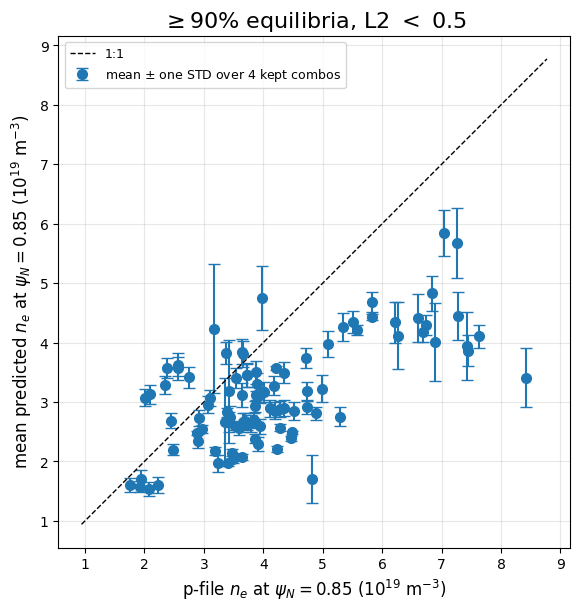

Plotted 96 / 100 equilibria using 4 kept combinations (quantity: ne)
Skipped (no kept combo converged): ['156826.04300', '156827.04300', '157102.02000', '157312.04575']


In [25]:
# For every equilibrium, compute mean ± std of n_e at psi_N_plot using ONLY the
# parameter combinations kept by the previous cell (filtered_combos).
# - If a kept combo did not converge for an equilibrium (no saved .npy), it is
#   simply excluded from that equilibrium's mean / error bar.
# - The equilibrium is still plotted as long as at least one kept combo
#   converged on it.

from collections import defaultdict

psi_N_plot = 0.85           # psi_N at which to sample
psi_val_scan = 0.85         # psi_N_inner used in param_err.py (must match)


def read_pfile_ne(path):
    psi_arr, ne_arr = [], []
    in_ne_block = False
    with open(path) as f:
        for line in f:
            if "3 N Z A" in line:
                break
            if line.startswith("201"):
                in_ne_block = "ne(10^20/m^3)" in line
                continue
            if in_ne_block:
                psi, val, _ = line.split()
                psi_arr.append(float(psi))
                ne_arr.append(float(val))
    return np.array(psi_arr), np.array(ne_arr) * 1e20


def value_at_psi(x_grid, y_grid, x_at_psi):
    return float(interp1d(
        x_grid, y_grid, kind="linear",
        bounds_error=False, fill_value="extrapolate",
    )(x_at_psi))


def npy_path_for(eq_tag, ac, ck, de, nf, nc, psi_val=psi_val_scan):
    return scan_success_dir / eq_tag / (
        f"ne_a{ac}_C{ck}_D{de}_n{nf}_nc{nc}_b{psi_val:.4f}.npy"
    )


if bc_type == "neumann":
    plot_quantity = "ne"
elif bc_type == "dirichlet":
    plot_quantity = "dne_dx"
else:
    raise ValueError(f"bc_type must be 'neumann' or 'dirichlet', got {bc_type!r}")

if not filtered_combos:
    print("No robust combinations in filtered_combos — run the previous cell first.")
else:
    # For each equilibrium, collect predictions only from kept combos that have
    # a saved .npy (i.e. converged on that equilibrium).
    combo_runs_by_eq = defaultdict(list)

    n_kept_combos = len(filtered_combos)
    n_runs_loaded = 0
    n_combos_missing_for_eq = 0

    for combo_key in filtered_combos:
        ac, ck, de, nf, nc = combo_key
        for mhd_fp, _ in equilibria:
            eq_tag = Path(mhd_fp).name[1:]
            npy_path = npy_path_for(eq_tag, ac, ck, de, nf, nc)
            if not npy_path.exists():
                n_combos_missing_for_eq += 1
                continue
            sol = np.load(npy_path, allow_pickle=True).item()
            combo_runs_by_eq[eq_tag].append({
                "x": np.asarray(sol["x"], dtype=float),
                "ne": np.asarray(sol["y"], dtype=float),
            })
            n_runs_loaded += 1

    print(
        f"Loaded {n_runs_loaded} converged runs across {n_kept_combos} kept combos "
        f"and {len(equilibria)} equilibria; "
        f"{n_combos_missing_for_eq} (combo, eq) pairs had no saved run and were skipped."
    )

    pfile_cache = {}
    geometry_cache = {}
    pfile_pts, pred_mean_pts, pred_std_pts, eq_labels, skipped = [], [], [], [], []

    for mhd_fp, kprof_fp in equilibria:
        eq_tag = Path(mhd_fp).name[1:]
        runs = combo_runs_by_eq.get(eq_tag, [])
        if not runs:
            skipped.append(eq_tag)
            continue

        if plot_quantity == "ne":
            # Scan used psi_N_inner = psi_val_scan, so sample at the inner boundary x.
            x_at_psi = min(float(r["x"].min()) for r in runs)

            if kprof_fp not in pfile_cache:
                pfile_cache[kprof_fp] = read_pfile_ne(kprof_fp)
            psi_pfile, ne_pfile = pfile_cache[kprof_fp]
            pfile_val = float(interp1d(
                psi_pfile, ne_pfile, kind="linear",
                bounds_error=False, fill_value="extrapolate",
            )(psi_N_plot))

            pred_vals = [value_at_psi(r["x"], r["ne"], x_at_psi) for r in runs]
        else:
            # Dirichlet still needs psi_N -> x mapping from equilibrium geometry.
            if eq_tag not in geometry_cache:
                ref = saarelma_connor_nondim(
                    P_tot_e=5e6,
                    alpha_crit=0,
                    C_KBM=0,
                    De_chie_etg=0,
                    nFC_x0=0,
                    ncx_x0_ratio=0,
                    mhd_fp=mhd_fp,
                    kprof_fp=kprof_fp,
                    verbose=False,
                )
                ref.setup_solver_grids(res=40)
                geometry_cache[eq_tag] = ref
            ref = geometry_cache[eq_tag]

            psi_to_x = interp1d(
                ref.psi_N_pres, ref.x_init,
                kind="linear", bounds_error=False, fill_value="extrapolate",
            )
            x_at_psi = float(psi_to_x(psi_N_plot))
            dne_dx_pfile = np.gradient(ref.n_e_pres, ref.x_init)
            pfile_val = value_at_psi(ref.x_init, dne_dx_pfile, x_at_psi)

            pred_vals = [
                value_at_psi(r["x"], np.gradient(r["ne"], r["x"]), x_at_psi)
                for r in runs
            ]

        pfile_pts.append(pfile_val)
        pred_mean_pts.append(float(np.mean(pred_vals)))
        pred_std_pts.append(float(np.std(pred_vals)))
        eq_labels.append(eq_tag)

    if not pfile_pts:
        print("No data to plot — check filtered_combos and psi_N_plot.")
        if skipped:
            print(f"Skipped equilibria (no kept combo converged): {skipped}")
    else:
        pfile_pts = np.array(pfile_pts)
        pred_mean_pts = np.array(pred_mean_pts)
        pred_std_pts = np.array(pred_std_pts)

        fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

        if plot_quantity == "ne":
            x_plot = pfile_pts / 1e19
            y_plot = pred_mean_pts / 1e19
            yerr = pred_std_pts / 1e19
            xlabel = rf"p-file $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)"
            ylabel = rf"mean predicted $n_e$ at $\psi_N={psi_N_plot}$ ($10^{{19}}$ m$^{{-3}}$)"
        else:
            x_plot = pfile_pts
            y_plot = pred_mean_pts
            yerr = pred_std_pts
            xlabel = rf"p-file $dn_e/dx$ at $\psi_N={psi_N_plot}$ (m$^{{-4}}$)"
            ylabel = rf"mean predicted $dn_e/dx$ at $\psi_N={psi_N_plot}$ (m$^{{-4}}$)"

        ax.errorbar(
            x_plot, y_plot, yerr=yerr,
            fmt="o", ms=7, capsize=4, lw=1.5,
            label=f"mean $\\pm$ one STD over {n_kept_combos} kept combos",
        )

        lo = min(x_plot.min(), (y_plot - yerr).min())
        hi = max(x_plot.max(), (y_plot + yerr).max())
        pad = 0.05 * (hi - lo) if hi > lo else 1.0
        ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=1, label="1:1")

        ax.set_xlabel(xlabel, fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(
            rf"$\geq${perc_success*100:.0f}% equilibria, L2 $<$ {err_frac}",
            fontsize=16,
        )
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_aspect("equal", adjustable="box")
        plt.savefig(f"ne_vs_pfile_at_psiN_{psi_N_plot}_{len(eq_labels)}equil.png")
        plt.show()

        print(
            f"Plotted {len(eq_labels)} / {len(equilibria)} equilibria "
            f"using {n_kept_combos} kept combinations (quantity: {plot_quantity})"
        )
        if skipped:
            print(f"Skipped (no kept combo converged): {skipped}")